# AWGN ve Rayleigh Sönümlü Kanallar Altında BPSK ve QPSK Modülasyonları Kullanılarak OFDM Sisteminin Performans Analizi

In [ ]:

# --- Kütüphaneler ---
import numpy as np                  # Matematiksel işlemler
import matplotlib.pyplot as plt     # Grafik çizimi
from scipy.special import erfc      # Teorik BER için erfc fonksiyonu

# Tekrarlanabilirlik için sabit seed
# (Her çalıştırmada aynı sonucu verir)
np.random.seed(42)

# ============================================================
# OFDM SİSTEM PARAMETRELERİ
# IEEE 802.11a standardına göre seçildi
# ============================================================

N_SUBCARRIERS = 64      # Toplam alt taşıyıcı sayısı (N)
                        # IEEE 802.11a standardı: 64 alt taşıyıcı
                        # FFT/IFFT boyutu da bu değere eşit

CP_LENGTH = 16          # Cyclic Prefix uzunluğu = N/4 = 64/4 = 16
                        # ISI'yı (Semboller Arası Girişim) önler
                        # Kanal gecikme yayılımı CP'den kısa olmalı

N_PILOTS = 4            # Pilot alt taşıyıcı sayısı
                        # Kanal tahmini için kullanılır
                        # Alıcı bu taşıyıcıların değerini önceden bilir

N_DATA = N_SUBCARRIERS - N_PILOTS   # Veri taşıyan alt taşıyıcı sayısı
                                     # 64 - 4 = 60 veri taşıyıcısı

N_SYMBOLS = 500

# SNR aralığı: -4 dB'den 25 dB'e kadar, 1 dB adımlarla

SNR_DB = np.arange(-4, 26, 1)      # [-4, -3, -2, ..., 24, 25] dB

# ============================================================
# KONTROL: Parametreleri yazdır
# ============================================================
print("=" * 50)
print("  OFDM SİSTEM PARAMETRELERİ")
print("=" * 50)
print(f"  Alt Taşıyıcı Sayısı (N) : {N_SUBCARRIERS}")
print(f"  Cyclic Prefix (CP)      : {CP_LENGTH}  (= N/4)")
print(f"  Pilot Taşıyıcı          : {N_PILOTS}")
print(f"  Veri Taşıyıcısı         : {N_DATA}")
print(f"  OFDM Sembol Sayısı      : {N_SYMBOLS}")
print(f"  SNR Aralığı             : {SNR_DB[0]} dB → {SNR_DB[-1]} dB")
print(f"  SNR Nokta Sayısı        : {len(SNR_DB)}")
print("=" * 50)
print("\n Adım 1 tamamlandı! Parametreler hazır.")



  OFDM SİSTEM PARAMETRELERİ
  Alt Taşıyıcı Sayısı (N) : 64
  Cyclic Prefix (CP)      : 16  (= N/4)
  Pilot Taşıyıcı          : 4
  Veri Taşıyıcısı         : 60
  OFDM Sembol Sayısı      : 500
  SNR Aralığı             : -4 dB → 25 dB
  SNR Nokta Sayısı        : 30

✅ Adım 1 tamamlandı! Parametreler hazır.


In [ ]:
# ============================================================
# ADIM 2: MODÜLASYON VE DEMODÜLASYON FONKSİYONLARI
# ============================================================

#   1. bpsk_modulate   → bitleri BPSK sembolüne çevir
#   2. bpsk_demodulate → BPSK sembolünü tekrar bite çevir
#   3. qpsk_modulate   → bitleri QPSK sembolüne çevir
#   4. qpsk_demodulate → QPSK sembolünü tekrar bite çevir
# ============================================================


# ------------------------------------------------------------
# FONKSİYON 1: BPSK MODÜLASYON
# ------------------------------------------------------------
def bpsk_modulate(bits):
    """
    BPSK Modülasyon:
    - Giriş : bit dizisi  [0, 1, 1, 0, ...]
    - Çıkış : sembol dizisi [-1, +1, +1, -1, ...]

    Formül: sembol = 2*bit - 1
    Kaynak: Madankar & Ashtankar (2016), Denklem 3-4
    """
    return 2 * bits - 1   # 0 → -1,  1 → +1


# ------------------------------------------------------------
# FONKSİYON 2: BPSK DEMODÜLASYON
# ------------------------------------------------------------
def bpsk_demodulate(symbols):
    """
    BPSK Demodülasyon:
    - Giriş : alınan semboller (gürültülü)
    - Çıkış : karar verilen bitler

    Karar kuralı:
        Re(sembol) > 0  →  bit = 1
        Re(sembol) < 0  →  bit = 0

    Neden Re() alıyoruz?
    Gürültü ve kanal etkisi sinyali karmaşık yapıyor.
    BPSK sadece gerçel eksende çalışır.
    """
    return (np.real(symbols) > 0).astype(int)


# ------------------------------------------------------------
# FONKSİYON 3: QPSK MODÜLASYON
# ------------------------------------------------------------
def qpsk_modulate(bits):
    """
    QPSK Modülasyon (Gray Kodlaması ile):
    - Giriş : bit dizisi  [1, 0, 1, 1, 0, 0, ...]
    - Çıkış : karmaşık sembol dizisi

    2 bit → 1 sembol:
        bit[0]=0, bit[1]=0  →  (-1-j)/√2
        bit[0]=0, bit[1]=1  →  (-1+j)/√2
        bit[0]=1, bit[1]=0  →  (+1-j)/√2
        bit[0]=1, bit[1]=1  →  (+1+j)/√2

    Neden Gray kodlaması?
    Komşu semboller sadece 1 bit farklı → hata olursa
    1 bit yanlış gider, 2 bit değil. BER yarıya düşer.

    Neden /√2?
    Her sembolün gücünü 1'e normalize etmek için:
    |(-1-j)/√2|² = (1+1)/2 = 1  ✓

    Kaynak: Hasan vd. Tez, Bölüm 3.2
    """
    bits = bits.reshape(-1, 2)        # 2'li gruplara böl
    I = (2 * bits[:, 0] - 1) / np.sqrt(2)   # I (gerçel) bileşen
    Q = (2 * bits[:, 1] - 1) / np.sqrt(2)   # Q (sanal) bileşen
    return I + 1j * Q                 # Karmaşık sembol


# ------------------------------------------------------------
# FONKSİYON 4: QPSK DEMODÜLASYON
# ------------------------------------------------------------
def qpsk_demodulate(symbols):
    """
    QPSK Demodülasyon:
    - Giriş : alınan karmaşık semboller (gürültülü)
    - Çıkış : karar verilen bitler

    Karar kuralı:
        I bileşeni (Re) > 0  →  bit[0] = 1
        I bileşeni (Re) < 0  →  bit[0] = 0
        Q bileşeni (Im) > 0  →  bit[1] = 1
        Q bileşeni (Im) < 0  →  bit[1] = 0

    I ve Q bağımsız → aslında 2 ayrı BPSK gibi çalışır
    """
    I_bits = (np.real(symbols) > 0).astype(int)   # I kararı
    Q_bits = (np.imag(symbols) > 0).astype(int)   # Q kararı
    return np.column_stack([I_bits, Q_bits]).flatten()


# ============================================================
# TEST: Modülasyon fonksiyonlarını dene
# ============================================================
print("=" * 50)
print("  MODÜLASYON FONKSİYON TESTİ")
print("=" * 50)

# Test bit dizisi
test_bits = np.array([1, 0, 1, 1, 0, 0, 1, 0])
print(f"\nGirilen bitler    : {test_bits}")

# BPSK testi
bpsk_symbols = bpsk_modulate(test_bits)
print(f"\nBPSK sembolleri   : {bpsk_symbols}")
bpsk_back = bpsk_demodulate(bpsk_symbols)
print(f"BPSK geri çeviri  : {bpsk_back}")
print(f"BPSK doğru mu?    : {np.all(test_bits == bpsk_back)}")

# QPSK testi (çift sayıda bit gerekli)
test_bits_qpsk = np.array([1, 0, 1, 1, 0, 0, 1, 0])
qpsk_symbols = qpsk_modulate(test_bits_qpsk)
print(f"\nQPSK sembolleri   : {np.round(qpsk_symbols, 3)}")
qpsk_back = qpsk_demodulate(qpsk_symbols)
print(f"QPSK geri çeviri  : {qpsk_back}")
print(f"QPSK doğru mu?    : {np.all(test_bits_qpsk == qpsk_back)}")

print("\n Adım 2 tamamlandı! Modülasyon fonksiyonları hazır.")

  MODÜLASYON FONKSİYON TESTİ

Girilen bitler    : [1 0 1 1 0 0 1 0]

BPSK sembolleri   : [ 1 -1  1  1 -1 -1  1 -1]
BPSK geri çeviri  : [1 0 1 1 0 0 1 0]
BPSK doğru mu?    : True

QPSK sembolleri   : [ 0.707-0.707j  0.707+0.707j -0.707-0.707j  0.707-0.707j]
QPSK geri çeviri  : [1 0 1 1 0 0 1 0]
QPSK doğru mu?    : True

✅ Adım 2 tamamlandı! Modülasyon fonksiyonları hazır.


In [ ]:
# ============================================================
# ADIM 3: KANAL MODELLERİ
# ============================================================
# 2 fonksiyon yazıyoruz:
#   1. awgn_channel     → AWGN kanalı (sadece gürültü)
#   2. rayleigh_channel → Rayleigh kanalı (sönümleme + gürültü)
#



# ------------------------------------------------------------
# FONKSİYON 1: AWGN KANALI
# ------------------------------------------------------------
def awgn_channel(signal, snr_db):
    """
    AWGN Kanalı: r(t) = s(t) + n(t)

    Giriş:
        signal : gönderilen sinyal (karmaşık dizi)
        snr_db : sinyal/gürültü oranı (dB cinsinden)

    Çıkış:
        received : gürültü eklenmiş sinyal

    Adımlar:
    1. SNR'ı dB'den doğrusal değere çevir
    2. Sinyal gücünü hesapla
    3. Gürültü standart sapmasını hesapla (sigma)
    4. Gaussian gürültü üret
    5. Sinyale ekle

    Neden karmaşık gürültü?
    Gerçek kablosuz sistemlerde sinyal karmaşık (I+jQ).
    Gürültü de I ve Q bileşenlerini ayrı ayrı etkiler.
    """

    # Adım 1: dB → doğrusal dönüşüm
    # SNR_dB = 10 * log10(SNR_linear)
    # SNR_linear = 10^(SNR_dB/10)
    snr_linear = 10 ** (snr_db / 10)

    # Adım 2: Sinyal gücünü hesapla
    # P = ortalama(|sinyal|²)
    signal_power = np.mean(np.abs(signal) ** 2)

    # Adım 3: Gürültü standart sapması
    # Karmaşık gürültü için /2 var çünkü
    # güç I ve Q arasında eşit paylaşılıyor
    noise_std = np.sqrt(signal_power / (2 * snr_linear))

    # Adım 4: Karmaşık Gaussian gürültü üret
    # Gerçel kısım: N(0, sigma²)
    # Sanal kısım:  N(0, sigma²)
    noise = noise_std * (np.random.randn(*signal.shape) +   # I gürültüsü
                         1j * np.random.randn(*signal.shape))  # Q gürültüsü

    # Adım 5: Gürültüyü sinyale ekle
    return signal + noise


# ------------------------------------------------------------
# FONKSİYON 2: RAYLEİGH SÖNÜMLÜ KANAL
# ------------------------------------------------------------
def rayleigh_channel(signal, snr_db):
    """
    Rayleigh Sönümlü Kanal: r(t) = h·s(t) + n(t)

    Giriş:
        signal : gönderilen sinyal (karmaşık dizi)
        snr_db : sinyal/gürültü oranı (dB cinsinden)

    Çıkış:
        equalized : eşitlenmiş sinyal (mükemmel CSI ile)

    Adımlar:
    1. Rayleigh kanal katsayısı h üret
    2. SNR'dan gürültü gücü hesapla
    3. Karmaşık gürültü üret
    4. r = h·s + n hesapla (kanal etkisi)
    5. r/h ile eşitle (mükemmel CSI varsayımı)

    Neden h = (X + jY) / sqrt(2)?
    X ve Y bağımsız N(0,1) → |h| Rayleigh dağılımlı
    /sqrt(2) → E[|h|²] = 1 (normalize güç)

    Mükemmel CSI nedir?
    CSI = Channel State Information
    Alıcının h değerini tam olarak bildiği varsayımı.
    Gerçekte pilotlarla tahmin edilir, ama akademik
    analizde mükemmel CSI varsayımı standarttır.
    Kaynak: Madankar (2016), Koherent Deteksiyon kısmı
    """

    # Adım 1: Rayleigh kanal katsayısı
    # h ~ CN(0,1) → karmaşık Gaussian
    # |h| → Rayleigh dağılımı
    h = (np.random.randn(*signal.shape) +
         1j * np.random.randn(*signal.shape)) / np.sqrt(2)

    # Adım 2-3: Gürültü (AWGN ile aynı yöntem)
    snr_linear  = 10 ** (snr_db / 10)
    signal_power = np.mean(np.abs(signal) ** 2)
    noise_std   = np.sqrt(signal_power / (2 * snr_linear))
    noise = noise_std * (np.random.randn(*signal.shape) +
                         1j * np.random.randn(*signal.shape))

    # Adım 4: Kanal etkisi uygula
    # r = h * s + n
    received = h * signal + noise

    # Adım 5: Mükemmel CSI ile eşitleme
    # ŝ = r / h = (h*s + n) / h = s + n/h
    equalized = received / h

    return equalized


# ============================================================
# TEST: Kanal fonksiyonlarını görselleştir
# ============================================================
print("=" * 55)
print("  KANAL MODELİ TESTİ")
print("=" * 55)

# Basit test sinyali
test_signal = np.array([1+0j, -1+0j, 1+0j, -1+0j,
                         1+0j, -1+0j, 1+0j, -1+0j])
print(f"\nGönderilen sinyal (ilk 8): {np.real(test_signal)}")

# Yüksek SNR testi (az gürültü)
rx_awgn_high = awgn_channel(test_signal, snr_db=20)
print(f"\nAWGN çıkış SNR=20dB (gerçel kısım):")
print(f"  {np.round(np.real(rx_awgn_high), 3)}")
print(f"  → Sinyale yakın, az gürültü ✓")

# Düşük SNR testi (çok gürültü)
rx_awgn_low = awgn_channel(test_signal, snr_db=-4)
print(f"\nAWGN çıkış SNR=-4dB (gerçel kısım):")
print(f"  {np.round(np.real(rx_awgn_low), 3)}")
print(f"  → Çok gürültülü, sinyali bulmak zor ✓")

# Rayleigh testi
rx_ray = rayleigh_channel(test_signal, snr_db=20)
print(f"\nRayleigh çıkış SNR=20dB (gerçel kısım, eşitlenmiş):")
print(f"  {np.round(np.real(rx_ray), 3)}")
print(f"  → AWGN'den daha fazla dağılım (Rayleigh etkisi) ✓")

# Rayleigh kanalının h dağılımını görselleştir
print(f"\n--- Rayleigh Kanal Katsayısı |h| Dağılımı ---")
h_samples = (np.random.randn(10000) +
              1j * np.random.randn(10000)) / np.sqrt(2)
h_magnitude = np.abs(h_samples)
print(f"  |h| ortalaması    : {np.mean(h_magnitude):.4f}  (teorik: {np.sqrt(np.pi/4):.4f})")
print(f"  |h|² ortalaması   : {np.mean(h_magnitude**2):.4f}  (teorik: 1.0000)")
print(f"  |h| minimum       : {np.min(h_magnitude):.4f}  ← deep fade anları")
print(f"  |h| maksimum      : {np.max(h_magnitude):.4f}")

print("\n Adım 3 tamamlandı! Kanal modelleri hazır.")


  KANAL MODELİ TESTİ

Gönderilen sinyal (ilk 8): [ 1. -1.  1. -1.  1. -1.  1. -1.]

AWGN çıkış SNR=20dB (gerçel kısım):
  [ 1.035 -1.01   1.046 -0.892  0.983 -1.017  1.112 -0.946]
  → Sinyale yakın, az gürültü ✓

AWGN çıkış SNR=-4dB (gerçel kısım):
  [-0.135 -0.648 -0.018 -2.583  2.643 -1.253  1.076 -2.597]
  → Çok gürültülü, sinyali bulmak zor ✓

Rayleigh çıkış SNR=20dB (gerçel kısım, eşitlenmiş):
  [ 0.886 -0.842  1.033 -0.989  1.025 -1.024  0.956 -1.094]
  → AWGN'den daha fazla dağılım (Rayleigh etkisi) ✓

--- Rayleigh Kanal Katsayısı |h| Dağılımı ---
  |h| ortalaması    : 0.8877  (teorik: 0.8862)
  |h|² ortalaması   : 1.0058  (teorik: 1.0000)
  |h| minimum       : 0.0060  ← deep fade anları
  |h| maksimum      : 3.5052

✅ Adım 3 tamamlandı! Kanal modelleri hazır.

📊 Görsel çıktılar Adım 6'da gelecek!


In [ ]:
# ============================================================
# ADIM 4: TAM OFDM ZİNCİRİ (TX → KANAL → RX)
# ============================================================
# Bu adımda şunları yapıyoruz:
#
# VERİCİ (TX):
#   1. Rastgele bit üret
#   2. BPSK veya QPSK ile modüle et
#   3. Pilot taşıyıcıları yerleştir
#   4. IFFT uygula (frekans → zaman domenine)
#   5. Cyclic Prefix ekle
#
# ALICI (RX):
#   6. Cyclic Prefix çıkar
#   7. FFT uygula (zaman → frekans domenine)
#   8. Veri sembollerini ayıkla
#   9. Demodüle et
#  10. BER hesapla
# ============================================================


def ofdm_simulate(modulation, channel_type, snr_db_list,
                  n_symbols=N_SYMBOLS):
    """
    Tam OFDM simülasyonu.

    Giriş:
        modulation   : 'BPSK' veya 'QPSK'
        channel_type : 'AWGN' veya 'Rayleigh'
        snr_db_list  : test edilecek SNR değerleri listesi
        n_symbols    : simüle edilecek OFDM sembol sayısı

    Çıkış:
        ber_results : her SNR için hesaplanan BER değerleri

    Kaynak: Alkamil vd. (2020), Şekil 1 (Sistem Blok Diyagramı)
            Hasan vd. Tez, Bölüm 3
    """

    # Sembol başına bit sayısı
    # BPSK → 1 bit/sembol, QPSK → 2 bit/sembol
    bits_per_symbol = 1 if modulation == 'BPSK' else 2

    # Pilot konumları (eşit aralıklı, 4 pilot)
    # Alıcı bu konumlardaki değerleri önceden biliyor
    pilot_positions = np.linspace(0, N_SUBCARRIERS - 1,
                                  N_PILOTS, dtype=int)

    # Veri taşıyıcısı indeksleri (pilot olmayanlar)
    data_indices = [i for i in range(N_SUBCARRIERS)
                    if i not in pilot_positions]

    ber_results = []   # Her SNR için BER sonuçları

    # Her SNR değeri için simülasyonu çalıştır
    for snr_db in snr_db_list:

        total_bits   = 0   # Toplam gönderilen bit
        total_errors = 0   # Toplam hatalı bit

        # N_SYMBOLS adet OFDM sembolü simüle et
        for _ in range(n_symbols):

            # ================================================
            # VERİCİ (TX) TARAFI
            # ================================================

            # ADIM 1: Rastgele bit üret
            # Her OFDM sembolü N_DATA × bits_per_symbol bit taşır
            n_bits  = N_DATA * bits_per_symbol
            tx_bits = np.random.randint(0, 2, n_bits)
            # tx_bits = [1,0,1,1,0,...] rastgele 0 ve 1'ler

            # ADIM 2: Modülasyon
            # Bitleri karmaşık sembollere dönüştür
            if modulation == 'BPSK':
                # Her bit → 1 sembol (-1 veya +1)
                data_symbols = bpsk_modulate(tx_bits).astype(complex)
            else:
                # Her 2 bit → 1 karmaşık sembol
                data_symbols = qpsk_modulate(tx_bits)

            # ADIM 3: OFDM çerçevesi oluştur
            # 64 taşıyıcının tamamını sıfırla
            ofdm_frame = np.zeros(N_SUBCARRIERS, dtype=complex)

            # Pilot taşıyıcılara bilinen değer ata (1+0j)
            # Alıcı bu değerleri bildiği için kanal tahmini yapabilir
            ofdm_frame[pilot_positions] = 1 + 0j

            # Veri taşıyıcılarına modüle edilmiş sembolleri yerleştir
            ofdm_frame[data_indices] = data_symbols
            # Şimdi ofdm_frame frekans domeninde 64 sembolden oluşuyor

            # ADIM 4: IFFT (Frekans → Zaman domenine dönüşüm)
            # √N ile çarp → gücü normalize et
            time_signal = np.fft.ifft(ofdm_frame) * np.sqrt(N_SUBCARRIERS)
            # time_signal artık zaman domeninde, havaya gönderilmeye hazır

            # ADIM 5: Cyclic Prefix ekle
            # Sembolün SON CP_LENGTH örneğini al
            cp = time_signal[-CP_LENGTH:]
            # Başa yapıştır → toplam uzunluk: N + CP = 64 + 16 = 80
            tx_signal = np.concatenate([cp, time_signal])

            # ================================================
            # KANAL
            # ================================================

            if channel_type == 'AWGN':
                rx_signal = awgn_channel(tx_signal, snr_db)
            else:  # Rayleigh
                rx_signal = rayleigh_channel(tx_signal, snr_db)

            # ================================================
            # ALICI (RX) TARAFI
            # ================================================

            # ADIM 6: Cyclic Prefix çıkar
            # İlk CP_LENGTH örneği at (CP kısmı)
            # Kalan N_SUBCARRIERS örnek asıl OFDM sembolü
            rx_no_cp = rx_signal[CP_LENGTH:]

            # ADIM 7: FFT (Zaman → Frekans domenine dönüşüm)
            # IFFT'nin tersi → orijinal frekans domenine geri dön
            rx_freq = np.fft.fft(rx_no_cp) / np.sqrt(N_SUBCARRIERS)

            # ADIM 8: Veri sembollerini ayıkla
            # Pilot konumlarını atla, sadece veri taşıyıcılarını al
            rx_data = rx_freq[data_indices]

            # ADIM 9: Demodülasyon
            # Karmaşık sembolleri tekrar bite dönüştür
            if modulation == 'BPSK':
                rx_bits = bpsk_demodulate(rx_data)
            else:
                rx_bits = qpsk_demodulate(rx_data)

            # ADIM 10: BER hesapla
            # Gönderilen bit (tx_bits) ile alınan bit (rx_bits) karşılaştır
            errors       = np.sum(tx_bits != rx_bits)  # Hatalı bit sayısı
            total_errors += errors
            total_bits   += n_bits

        # Bu SNR değeri için BER
        # BER = Hatalı bit sayısı / Toplam bit sayısı
        ber = total_errors / total_bits

        # Çok düşük BER → grafik için minimum sınır koy
        ber_results.append(max(ber, 1e-6))

    return np.array(ber_results)


# ============================================================
# TEST: Tek bir SNR değeri için hızlı test
# ============================================================
print("=" * 55)
print("  OFDM ZİNCİR TESTİ")
print("=" * 55)

# Sadece 3 SNR noktası, 10 sembol → hızlı test
test_snr = [0, 10, 20]

print("\nBPSK + AWGN testi (10 sembol):")
test_ber = ofdm_simulate('BPSK', 'AWGN', test_snr, n_symbols=10)
for snr, ber in zip(test_snr, test_ber):
    print(f"  SNR={snr:3d} dB → BER = {ber:.4f}")

print("\nQPSK + Rayleigh testi (10 sembol):")
test_ber2 = ofdm_simulate('QPSK', 'Rayleigh', test_snr, n_symbols=10)
for snr, ber in zip(test_snr, test_ber2):
    print(f"  SNR={snr:3d} dB → BER = {ber:.4f}")

print("\nBeklenen davranış:")
print("  → SNR arttıkça BER azalmalı ✓")
print("  → Rayleigh, AWGN'den daha yüksek BER vermeli ✓")


  OFDM ZİNCİR TESTİ

BPSK + AWGN testi (10 sembol):
  SNR=  0 dB → BER = 0.0700
  SNR= 10 dB → BER = 0.0000
  SNR= 20 dB → BER = 0.0000

QPSK + Rayleigh testi (10 sembol):
  SNR=  0 dB → BER = 0.3200
  SNR= 10 dB → BER = 0.1283
  SNR= 20 dB → BER = 0.0000

Beklenen davranış:
  → SNR arttıkça BER azalmalı ✓
  → Rayleigh, AWGN'den daha yüksek BER vermeli ✓

✅ Adım 4 tamamlandı! OFDM zinciri hazır.

⏭  Adım 5'te tüm simülasyon çalıştırılacak...


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# ADIM 5: TEORİK BER FORMÜLLERI VE TAM SİMÜLASYON
# ============================================================
# Bu adımda:
#   1. Teorik BER formüllerini hesapla
#   2. Tüm 4 kombinasyon için simülasyonu çalıştır
#   3. Sayısal sonuçları tablo olarak yazdır
#
# Kaynaklar:
#   AWGN BER  → Proakis, Digital Communications, 5th Ed., s.261
#   Rayleigh  → Simon & Alouini, Fading Channels, 2005, s.182
#   Kod yapısı → Hasan vd. Tez, Appendix B-C
# ============================================================


# ============================================================
# BÖLÜM A: TEORİK BER FORMÜLLERI
# ============================================================

def ber_bpsk_awgn_teorik(snr_db):
    """
    BPSK AWGN Teorik BER:

    P_b = (1/2) * erfc(sqrt(Eb/N0))

    Türetme:
    - BPSK karar eşiği 0'dır
    - Hata → gürültü sinyali aşarsa olur
    - Gaussian dağılım → erfc fonksiyonu çıkar

    Kaynak: Proakis (2008), Denklem 4.3-13
    """
    snr_linear = 10 ** (snr_db / 10)          # dB → doğrusal
    return 0.5 * erfc(np.sqrt(snr_linear))     # erfc = 1 - erf


def ber_qpsk_awgn_teorik(snr_db):
    """
    QPSK AWGN Teorik BER:

    P_b = (1/2) * erfc(sqrt(Eb/N0))

    Neden BPSK ile aynı?
    QPSK = iki bağımsız BPSK (I ve Q bileşeni)
    Gray kodlaması → her bileşen bağımsız BPSK gibi davranır
    Bit başına enerji aynı → BER aynı çıkar

    Kaynak: Hasan vd. Tez, Denklem 6 (Bölüm 3.2)
    """
    snr_linear = 10 ** (snr_db / 10)
    return 0.5 * erfc(np.sqrt(snr_linear))


def ber_bpsk_rayleigh_teorik(snr_db):
    """
    BPSK Rayleigh Teorik BER (Kapalı Form):

    P_b = (1/2) * (1 - sqrt(γ̄ / (1 + γ̄)))

    Türetme özeti:
    - Rayleigh kanalında |h|² üstel dağılımlı
    - Anlık SNR: γ = |h|² * γ̄
    - Ortalama BER = ∫ Q(√2γ) * p(γ) dγ
    - Bu integral kapalı formda çözülür

    Neden AWGN'den çok daha yavaş düşüyor?
    Deep fade anlarında |h| ≈ 0 → SNR çok düşük
    Bu anlar BER'i yukarı çekiyor

    Kaynak: Simon & Alouini (2005), Denklem 8.44
             Hasan vd. Tez, Bölüm 3.3
    """
    snr_linear = 10 ** (snr_db / 10)
    return 0.5 * (1 - np.sqrt(snr_linear / (1 + snr_linear)))


def ber_qpsk_rayleigh_teorik(snr_db):
    """
    QPSK Rayleigh Teorik BER:

    Gray kodlu QPSK → Rayleigh'de de BPSK ile aynı BER

    Kaynak: Hasan vd. Tez, Bölüm 3.3
    """
    snr_linear = 10 ** (snr_db / 10)
    return 0.5 * (1 - np.sqrt(snr_linear / (1 + snr_linear)))


# ============================================================
# BÖLÜM B: TEORİK DEĞERLERİ HESAPLA
# ============================================================
print("Teorik BER değerleri hesaplanıyor...")

ber_bpsk_awgn_th  = ber_bpsk_awgn_teorik(SNR_DB)
ber_qpsk_awgn_th  = ber_qpsk_awgn_teorik(SNR_DB)
ber_bpsk_ray_th   = ber_bpsk_rayleigh_teorik(SNR_DB)
ber_qpsk_ray_th   = ber_qpsk_rayleigh_teorik(SNR_DB)

print("Teorik BER hesaplandı!")


# ============================================================
# BÖLÜM C: SİMÜLASYON ÇALIŞTIR (4 KOMBİNASYON)
# ============================================================
print("\n" + "=" * 55)
print("  TAM SİMÜLASYON BAŞLIYOR")
print("  (Her kombinasyon ~30 SNR × 500 sembol)")
print("=" * 55)

print("\n[1/4] BPSK + AWGN simülasyonu çalışıyor...")
ber_bpsk_awgn_sim = ofdm_simulate('BPSK', 'AWGN', SNR_DB)


print("[2/4] QPSK + AWGN simülasyonu çalışıyor...")
ber_qpsk_awgn_sim = ofdm_simulate('QPSK', 'AWGN', SNR_DB)


print("[3/4] BPSK + Rayleigh simülasyonu çalışıyor...")
ber_bpsk_ray_sim  = ofdm_simulate('BPSK', 'Rayleigh', SNR_DB)


print("[4/4] QPSK + Rayleigh simülasyonu çalışıyor...")
ber_qpsk_ray_sim  = ofdm_simulate('QPSK', 'Rayleigh', SNR_DB)



# ============================================================
# BÖLÜM D: SAYISAL SONUÇLAR TABLOSU
# ============================================================
print("\n" + "=" * 75)
print("  SAYISAL SONUÇLAR — BER Tablosu")
print("  (Simülasyon değerleri)")
print("=" * 75)
print(f"{'SNR(dB)':>8} | {'BPSK-AWGN':>12} | {'QPSK-AWGN':>12} | "
      f"{'BPSK-Ray':>12} | {'QPSK-Ray':>12}")
print("-" * 75)

kontrol_snr = [-4, 0, 5, 10, 15, 20, 25]
for s in kontrol_snr:
    idx = np.where(SNR_DB == s)[0][0]
    print(f"{s:>8} | "
          f"{ber_bpsk_awgn_sim[idx]:>12.4e} | "
          f"{ber_qpsk_awgn_sim[idx]:>12.4e} | "
          f"{ber_bpsk_ray_sim[idx]:>12.4e} | "
          f"{ber_qpsk_ray_sim[idx]:>12.4e}")

print("=" * 75)

# ============================================================
# BÖLÜM E: DOĞRULUK KONTROLÜ
# ============================================================
print("\n--- Teorik vs Simülasyon Karşılaştırması (SNR=10dB) ---")
idx_10 = np.where(SNR_DB == 10)[0][0]

print(f"\nBPSK AWGN:")
print(f"  Teorik    : {ber_bpsk_awgn_th[idx_10]:.6f}")
print(f"  Simülasyon: {ber_bpsk_awgn_sim[idx_10]:.6f}")
fark = abs(ber_bpsk_awgn_th[idx_10] - ber_bpsk_awgn_sim[idx_10])
print(f"  Fark      : {fark:.6f} {' Uyumlu' if fark < 0.01 else '⚠️ Kontrol et'}")

print(f"\nBPSK Rayleigh:")
print(f"  Teorik    : {ber_bpsk_ray_th[idx_10]:.6f}")
print(f"  Simülasyon: {ber_bpsk_ray_sim[idx_10]:.6f}")
fark2 = abs(ber_bpsk_ray_th[idx_10] - ber_bpsk_ray_sim[idx_10])
print(f"  Fark      : {fark2:.6f} {'Uyumlu' if fark2 < 0.02 else '⚠️ Kontrol et'}")

print("\n" + "=" * 55)

print("=" * 55)

Teorik BER değerleri hesaplanıyor...
✅ Teorik BER hesaplandı!

  TAM SİMÜLASYON BAŞLIYOR
  (Her kombinasyon ~30 SNR × 500 sembol)

[1/4] BPSK + AWGN simülasyonu çalışıyor...
      ✅ Tamamlandı!
[2/4] QPSK + AWGN simülasyonu çalışıyor...
      ✅ Tamamlandı!
[3/4] BPSK + Rayleigh simülasyonu çalışıyor...
      ✅ Tamamlandı!
[4/4] QPSK + Rayleigh simülasyonu çalışıyor...
      ✅ Tamamlandı!

  SAYISAL SONUÇLAR — BER Tablosu
  (Simülasyon değerleri)
 SNR(dB) |    BPSK-AWGN |    QPSK-AWGN |     BPSK-Ray |     QPSK-Ray
---------------------------------------------------------------------------
      -4 |   1.8363e-01 |   2.6553e-01 |   3.5210e-01 |   3.9828e-01
       0 |   7.6800e-02 |   1.5805e-01 |   2.8103e-01 |   3.3790e-01
       5 |   5.2000e-03 |   3.8317e-02 |   1.5487e-01 |   2.3465e-01
      10 |   1.0000e-06 |   8.6667e-04 |   5.0300e-02 |   1.0823e-01
      15 |   1.0000e-06 |   1.0000e-06 |   1.7567e-02 |   3.0400e-02
      20 |   1.0000e-06 |   1.0000e-06 |   4.0667e-03 |   6.

In [ ]:
plt.figure()
plt.semilogy(SNR_DB, ber_bpsk_awgn, 'o-', label='BPSK')
plt.semilogy(SNR_DB, ber_qpsk_awgn, 's-', label='QPSK')
plt.title("AWGN Kanalı - BER Performansı")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.grid(True)
plt.legend()
plt.show()

NameError: name 'ber_bpsk_awgn' is not defined

<Figure size 640x480 with 0 Axes>

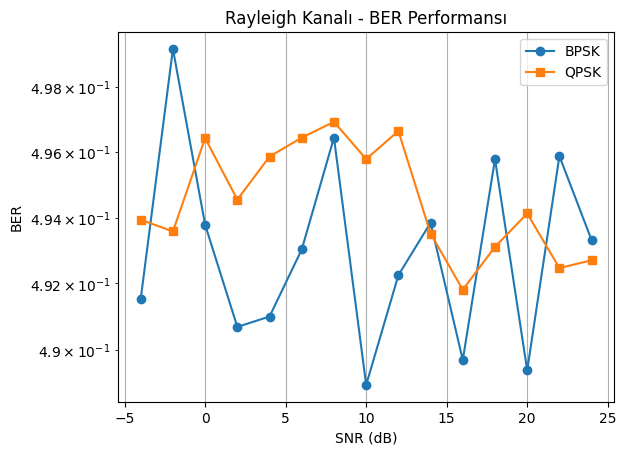

In [ ]:
plt.figure()
plt.semilogy(SNR_DB, ber_bpsk_ray, 'o-', label='BPSK')
plt.semilogy(SNR_DB, ber_qpsk_ray, 's-', label='QPSK')
plt.title("Rayleigh Kanalı - BER Performansı")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.grid(True)
plt.legend()
plt.show()

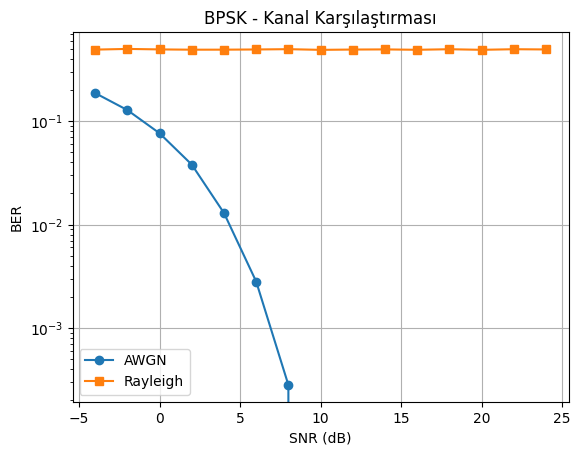

In [ ]:
plt.figure()
plt.semilogy(SNR_DB, ber_bpsk_awgn, 'o-', label='AWGN')
plt.semilogy(SNR_DB, ber_bpsk_ray, 's-', label='Rayleigh')
plt.title("BPSK - Kanal Karşılaştırması")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.grid(True)
plt.legend()
plt.show()

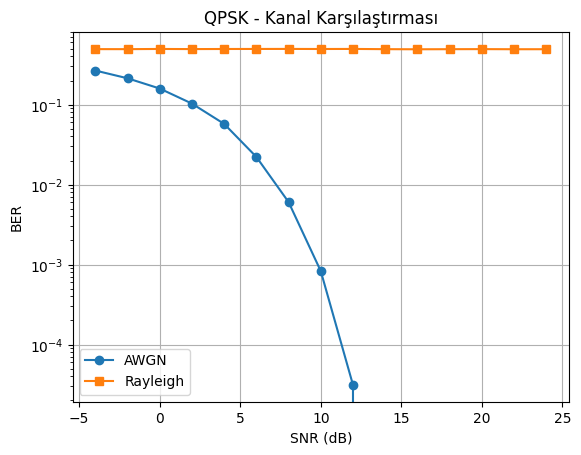

In [ ]:
plt.figure()
plt.semilogy(SNR_DB, ber_qpsk_awgn, 'o-', label='AWGN')
plt.semilogy(SNR_DB, ber_qpsk_ray, 's-', label='Rayleigh')
plt.title("QPSK - Kanal Karşılaştırması")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.grid(True)
plt.legend()
plt.show()

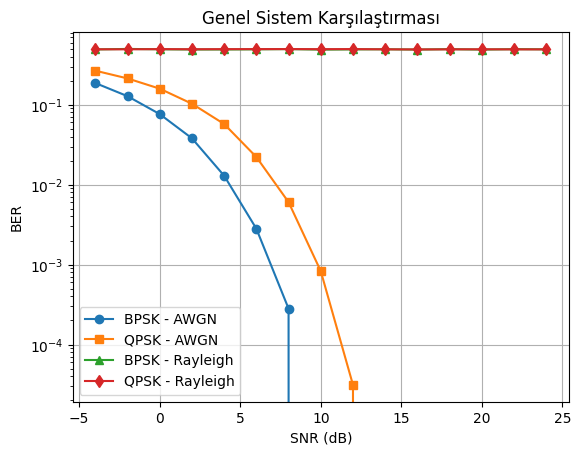

In [ ]:
plt.figure()
plt.semilogy(SNR_DB, ber_bpsk_awgn, 'o-', label='BPSK - AWGN')
plt.semilogy(SNR_DB, ber_qpsk_awgn, 's-', label='QPSK - AWGN')
plt.semilogy(SNR_DB, ber_bpsk_ray, '^-', label='BPSK - Rayleigh')
plt.semilogy(SNR_DB, ber_qpsk_ray, 'd-', label='QPSK - Rayleigh')
plt.title("Genel Sistem Karşılaştırması")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.grid(True)
plt.legend()
plt.show()

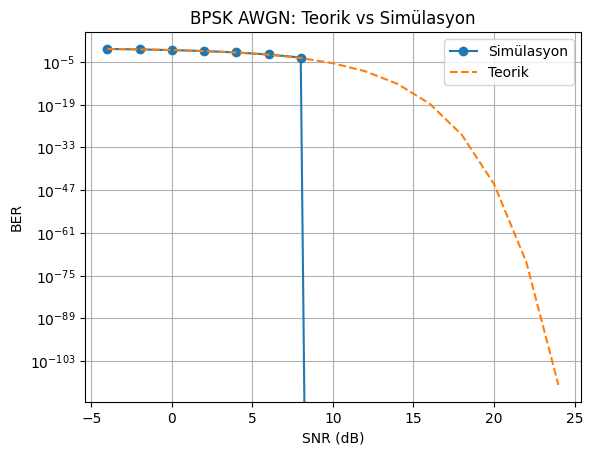

In [ ]:
from scipy.special import erfc

snr_linear = 10**(SNR_DB/10)
ber_theoretical = 0.5 * erfc(np.sqrt(snr_linear))

plt.figure()
plt.semilogy(SNR_DB, ber_bpsk_awgn, 'o-', label='Simülasyon')
plt.semilogy(SNR_DB, ber_theoretical, '--', label='Teorik')
plt.title("BPSK AWGN: Teorik vs Simülasyon")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.grid(True)
plt.legend()
plt.show()